# History Matching (Manual Configuration)

The history matching library can be used in a _manual_ mode, in which the user has control over the selection of emulators and their corresponding emulation targets or features, or _automatic_ mode, in which the selection of emulators and their targets is done internally within each history matching iteration without any intervention from the user.

This notebook shows how to use history matching in manual mode. It describes different ways of interacting with the library to run single or multiple history matching iterations, as well as how to inspect the performance of the trained emulators.

## Libraries, global parameters, and initialization

The basic libraries for numerical analysis are used throughout the notebook, namely, numpy and pandas. In addition, we need to import the `history_matching` package.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import history_matching as hm

%matplotlib inline

## Example scenario: a stochastic SIR model

Let's define a stochastic SIR model using the Tao-leap algorithm. This is the model we will calibrate using History Matching. Furthermore, we will use this model to generate synthetic data. Our calibration process will try to recover the parameters that generated the synthetic data.

### Model definition

In [2]:
class SIR:
    """ A stochastic SIR model. 
    """
    def __init__( self, 
                  beta=1.2,  gamma=0.3,        # transition rates
                  s0=990,  i0=10,  r0=0,       # initial conditions
                  n_days=20,                   # number of days to simulate
                  step=0.1,                    # step size in days (<=1)
                  seed=None,                   # random number seed
                 ):
        """ Create and initialize the SIR model.
        
        Args:
            beta   : Transmission rate (>0).
            gamma  : Inverse of the average transmission period (>0).
            s0     : Initial number of succeptible individuals (non-negative 
                     integer).
            i0     : Initial number of infected individuals (non-negative int).
            r0     : Initial number of recovered individuals (non-negative int).
            n_days : Number of days to simulate (positive integer).
            step   : Step size in days (integer between 0 and 1).
            seed   : Seed for the random number generator.
        """
        # Verify inputs
        assert( beta > 0 )
        assert( gamma > 0 )
        assert( s0 >= 0 )
        assert( i0 >= 0 )
        assert( r0 >= 0 )
        assert( n_days > 0 )
        assert( step > 0 )
        assert( step <= 1 )
        
        # Initialize variables
        self.beta = beta
        self.gamma = gamma
        self.s0 = int( s0 )
        self.i0 = int( i0 )
        self.r0 = int( r0 )
        self.n_days = int( n_days )
        self.step = step
        self.seed = seed
        self.simulation_complete = False

    
    def run( self ):
        """ Run the simulation and return S, I, and R arrays.
        """    
        # Initialization
        n_steps = math.ceil( (self.n_days-1)/self.step )
        steps_per_day = int( 1/self.step )
        N = self.s0 + self.i0 + self.r0    # population size             
        
        s = np.zeros( n_steps+1, dtype=int )
        i = np.zeros( n_steps+1, dtype=int )
        r = np.zeros( n_steps+1, dtype=int )        
        s[0] = self.s0
        i[0] = self.i0
        r[0] = self.r0

        s_daily = np.zeros( self.n_days, dtype=int )
        i_daily = np.zeros( self.n_days, dtype=int )
        r_daily = np.zeros( self.n_days, dtype=int )
        s_daily[0] = s[0]
        i_daily[0] = i[0]
        r_daily[0] = r[0]

        if self.seed is not None:
            np.random.seed( seed=self.seed )

        # Compute events per time step
        for j in range(1, n_steps+1):
            lambda_transmission = ( self.beta * s[j-1] * i[j-1] / N ) * self.step
            lambda_recovery = self.gamma * i[j-1] * self.step
                       
            delta_Mt = np.random.poisson( lambda_transmission )
            delta_Mr = np.random.poisson( lambda_recovery )
            
            s[j] = max( s[j-1] - delta_Mt           , 0 )
            i[j] = max( i[j-1] + delta_Mt - delta_Mr, 0 )
            r[j] = r[j-1] + delta_Mr

        # Count events per day
        for j in range(1, self.n_days):
            k = j*steps_per_day
            s_daily[j] = s[k]
            i_daily[j] = i[k]
            r_daily[j] = r[k]
        
        # Finalize and return
        self.s = s_daily
        self.i = i_daily
        self.r = r_daily
        self.simulation_complete = True
        return s_daily, i_daily, r_daily
    

    def get_incidence( self ): 
        """ Return array with the incidence.
        """
        if not self.simulation_complete:
            self.run()
        n = len(self.i)
        incidence = np.zeros(n)
        incidence[0] = 0
        for j in range(1, n):
            incidence[j] = self.s[j-1] - self.s[j]
        return incidence


    def plot( self ): 
        """ Display figure with S, I, and R curves.
        """
        if not self.simulation_complete:
            self.run()
        x = range(0, self.n_days)
        title = f'beta = {self.beta};  gamma = {self.gamma}'
        plt.figure()
        plt.plot( x, self.s, 'g')
        plt.plot( x, self.i, 'r')
        plt.plot( x, self.r, 'b')
        plt.legend(['S', 'I', 'R'])
        plt.ylabel('cases')
        plt.xlabel('days')
        plt.title( title )
        plt.grid(linestyle=':')
 

    def plot_incidence( self ): 
        """ Display figure with the incidence.
        """
        if not self.simulation_complete:
            self.run()
        incidence = self.get_incidence()
        x = range(0, self.n_days)
        title = f'beta = {self.beta};  gamma = {self.gamma}'
        plt.figure()
        plt.plot( x, incidence, 'b' )
        plt.ylabel('new cases')
        plt.xlabel('days')
        plt.title(title)
        plt.grid(linestyle=':')

### Running our model

Our model should be easy to run. Let's try it with a few different parameters:

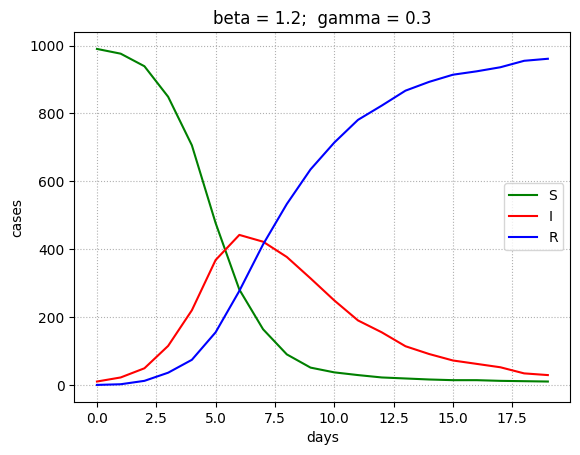

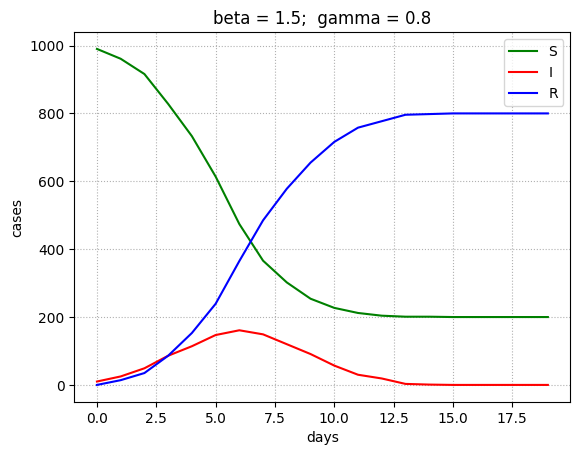

In [3]:
sim1 = SIR()
sim2 = SIR( beta=1.5, gamma=0.8 )
sim1.plot()
sim2.plot()

### Synthetic data

Next we generate synthetic data for the demonstration of the History Matching (HM) algorithm. We define specific values of the `beta` and `gamma` parameters. We will later use to recover (i.e., estimate) those parameters.

In [4]:
# Define model parameters
beta_true = 1.3
gamma_true = 0.5
rand_seed = 0
population_size = 10_000
n_seed_infections = 100

In [5]:
# Run the simulation
true_model = SIR( beta  = beta_true,
                  gamma = gamma_true,
                  s0    = population_size - n_seed_infections,
                  i0    = n_seed_infections,
                  seed  = rand_seed
                 )
S, I, R = true_model.run()

In [6]:
# Generate simulated observation data
incidence_data = true_model.get_incidence()
data = pd.DataFrame( { 'day' : range(0,len(incidence_data)), 
                       'incidence' : incidence_data
                      } ).set_index('day')

Let's quickly glance at our data:

In [7]:
data.head()

,incidence
day,
0,0.0
1,177.0
2,415.0
3,762.0
4,1246.0


<Axes: xlabel='day'>

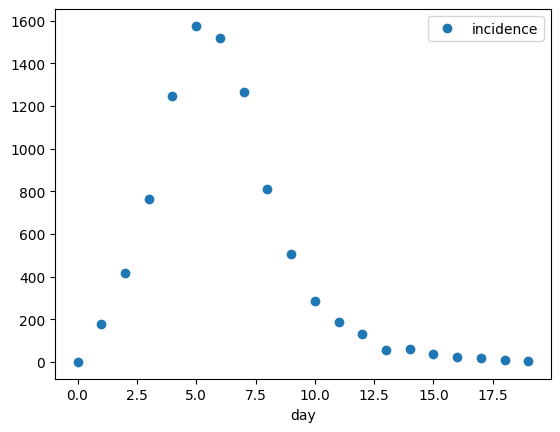

In [8]:
data.plot( style='o' )

## Running a History Matching iteration

### Iteration parameters

There are two parameters that are needed for running a history matching iteration, namely:
- `parameter_space`, which defines the name of our model parameters as well as their corresponding search intervals; and
- `observations`, which contain our observation data.

Let's see how to define each of them.

#### `parameter_space`

This parameter is a dataframe with one row for each one of the parameters, the index column containing the name of each parameters, and two data columns named "minimum" and "maximum" that contain the corresponding lower and upper bound for the parameters. In our example, we can define it as follows:

In [9]:
parameter_space = pd.DataFrame( { # name      ,   min , max
                                  'beta'      : [ 0.1, 5.0 ],
                                  'gamma'     : [ 0.1, 1.0 ],
                                  'rand_seed' : [ 0   , 1e5 ]
                                 }, index = ['minimum', 'maximum']
                               ).transpose()
parameter_space.index.name = 'parameter'
parameter_space.head()

,minimum,maximum
parameter,,
beta,0.1,5.0
gamma,0.1,1.0
rand_seed,0.0,100000.0


#### `observations`

The observations data is defined as a datrame with 3 columns for each sample point, namely: "feature", "mean", and "variance". The "feature" defines the name of the sample point. This is how we can define it in our example: 

In [10]:
observations = pd.DataFrame()
observations['feature'] = 'incidence_' + data.index.astype(str)
observations['mean'   ] = data['incidence']
observations['variance'] = 100 #np.maximum( 20, 0.2*data['incidence'] )
observations.head()

,feature,mean,variance
0,incidence_0,0.0,100
1,incidence_1,177.0,100
2,incidence_2,415.0,100
3,incidence_3,762.0,100
4,incidence_4,1246.0,100


### Interacting with the model

There are two ways of interacting with the model: (1) we can provide a wrapper function that receives a set of sample points, runs the model, and return the simulation results for that set of sample points; and (2) we can simply get the set of sample points as a .csv file, run the model, and save the simulation results in another .csv file to be ingested by the history matching function.

In both cases, both the set of sample points and the simulation results have a very specific format. The input sample points should be specified as a dataframe (or table) with rows corresponding to individual sets of points, and columns containing the values for each of the model parameters. The simulation results should be defined as a dataframe (or table) with each row containing the simulation result for the corresponding row in the input sample points, and with each column corresponding to individual outputs of the model.

Let's see these data formats as we build a wrapper function for history matching.

In [11]:
def sir_model_wrapper( points: pd.DataFrame ) -> pd.DataFrame:

    # Run simulations
    #results = pd.DataFrame()
    results = []

    for index, parameters in enumerate(points.itertuples()):

        this_run = SIR( beta  = parameters.beta,
                        gamma = parameters.gamma,
                        s0    = population_size - n_seed_infections,
                        i0    = n_seed_infections,
                        seed  = int(parameters.rand_seed)
                       )
        results.append( pd.Series(this_run.get_incidence()) )

    # Format output dataframe
    out = pd.concat(results, axis=1).transpose().add_prefix('incidence_')
    return out

Let's generate some sample points:

In [12]:
test_points = pd.DataFrame( { param: np.random.uniform( parameter_space.loc[param, 'minimum'], 
                                                                                         parameter_space.loc[param, 'maximum'],
                                                                                         100
                                                                                        ) for param in parameter_space.index 
                             } 
                            )
test_points.head()

,beta,gamma,rand_seed
0,2.145942,0.170421,52658.402882
1,3.929750,0.434158,53794.577915
2,3.499360,0.789932,93766.309396
3,4.590068,0.719815,30518.870269
4,1.370949,0.737184,98343.397823


And let's run our model with these sets of parameters to evaluate that the output has the right format for the history matching package.

In [13]:
test_results = sir_model_wrapper( test_points )
test_results.head()

,incidence_0,incidence_1,incidence_2,incidence_3,incidence_4,incidence_5,incidence_6,incidence_7,incidence_8,incidence_9,incidence_10,incidence_11,incidence_12,incidence_13,incidence_14,incidence_15,incidence_16,incidence_17,incidence_18,incidence_19
0,0.0,482.0,2135.0,4417.0,2319.0,432.0,86.0,19.0,9.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1973.0,6797.0,1063.0,55.0,8.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1132.0,4928.0,3121.0,487.0,99.0,20.0,10.0,8.0,3.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,2850.0,6427.0,545.0,47.0,9.0,5.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,182.0,314.0,475.0,742.0,1065.0,1091.0,1045.0,925.0,572.0,403.0,272.0,185.0,136.0,79.0,53.0,23.0,17.0,16.0,7.0


We can also see the incidence trajectories for the set of test points:

<Axes: >

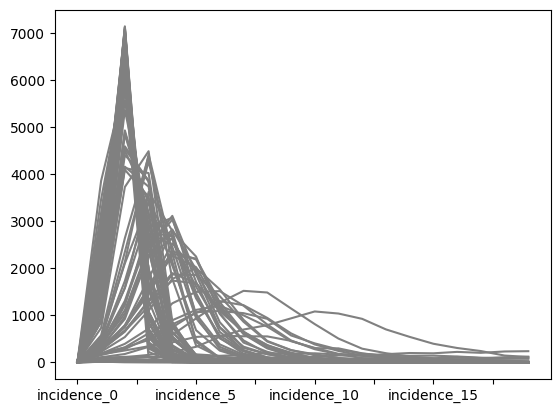

In [14]:
n_curves = 100
test_results.transpose().iloc[:,0:n_curves].plot( color='gray', legend=False )

## Running a single history matching iteration

#### Configuration

The first thing that we should do is to configure our history matching iteration. We do that by instantiating a `Config` object. The most basic instantiation (and configuration) uses only 3 parameters, as follows:

In [15]:
config = hm.Config( parameter_space = parameter_space.reset_index(),   # Get rid of "reset_index()"
                    observations = observations,
                    model = sir_model_wrapper
                   )

And with this configuration we can run one (or multiple) history matching iterations.

#### Running the iteration

We run a single history matching iteration by calling the function `do_step` and passing the instantiated configuration object. This function returns a trace of the history matching process. The trace is a list with items containing information about thd `do_step` calls (the first item contains information about the first call, the second item about the second call, and so on). The trace data for each `do_step` call includes the step or iteration number, the (trained) emulator bank, input data, and output sample, among other informational results. When running multiple steps of history matching, we should include the trace as an input parameter. If a trace is not included, a new one will be created by the `do_step` function. For example: 

```
trace_1  = do_step( config          )  # Runs the first step or iteration, and creates a new trace
trace_2  = do_step( config, trace_1 )  # Runs a second step, including all results up to the ones included in trace_1
trace_3  = do_step( config, trace_2 )  # Runs step 3
trace_3b = do_step( config, trace_2 )  # Runs step 3 again, but potentially changing the emulator target
```
In our example, we can do the first call to `do_step` as follows:

In [16]:
trace = hm.do_step( config )

Starting first History Matching iteration
... step_number = 1
... Running simulator


Loading BokehJS ...

Please enter the feature or summary statistic to use as target for the emulator:  incidence_11


... Training emulator for feature incidence_11
... Using emulator for feature incidence_11, which was trained at iteration number 1
New samples generated |----------------------------------------| 1.6% (a total of 500500 samples have been considered)
... unable to find new candidates after 500500 trials. Aborting the generation of new points.

Remaining non-implausible space: 0.001598%
Finished step 1.


## Check the iteration results

Once we have run a history matching iteration, we can go ahead and inspect the results. When doing that, we can look at different things, such as:
- Non-implausible parameter space, i.e., samples that describe the current solution space;
- Trajectory selection, i.e., selecting outputs (and their corresponding parameters) that look closer to the observation data; and
- Emulator configuration and characterization of performance.

### Characterization of the parameter space

The resulting parameter space is characterized by the set of non-implausible parameters generated by the last iteration of history matching. This set of parameters can be accessed by looking at the `new_samples` field of the last item in the trace. Indeed, we can look at the evolution of the parameter space (i.e., how the non-implausible region is reduced after each iteration) by looking at `new_samples` for each item in the trace.

In [17]:
samples_step_1 = trace[0]['new_samples']
samples_step_1.head()

,beta,gamma,rand_seed
107,2.3883,0.6517,74900.0
136,1.4377,0.7309,95700.0
169,1.1927,0.9883,47100.0
176,1.3103,0.7975,6100.0
178,0.2813,0.6139,31700.0


We can see how the parameter space is reduced after one iteration:

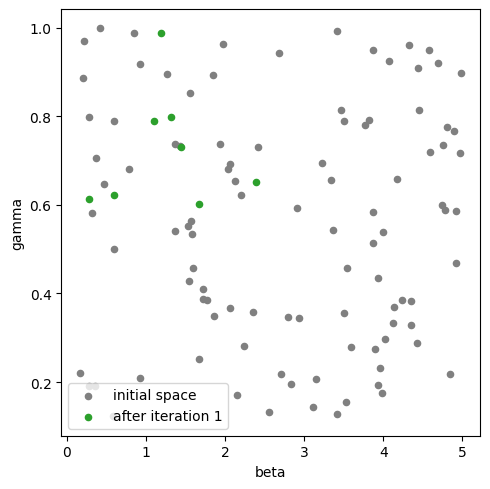

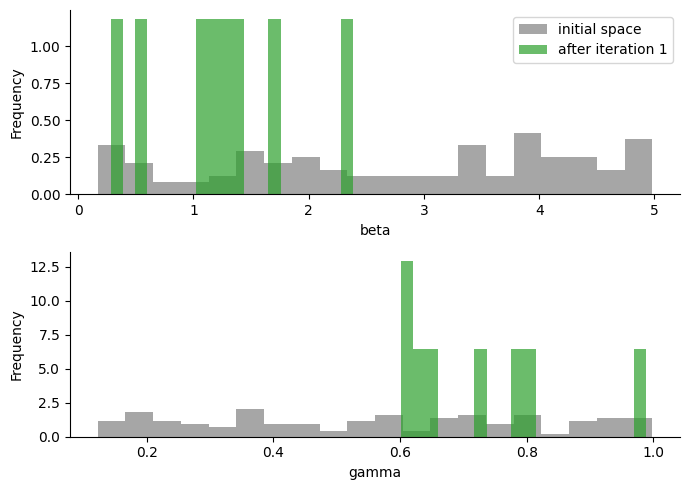

In [18]:
def plot_parameter_space( samples_1, samples_2, label_1='samples_1', label_2='samples_2', best_idx_samples_2=None ):

    # Figure/format parameters
    color_1 = 'gray'
    color_2 = 'tab:green'
    color_top = 'tab:orange'
    n_bins = 20
    
    # Draw scatter plot   
    fig_scatter, ax_scatter = plt.subplots( 1, 1, figsize=(5,5) )
    samples_1.plot.scatter( x='beta', y='gamma', c=color_1, label=label_1, ax=ax_scatter )
    samples_2.plot.scatter( x='beta', y='gamma', c=color_2, label=label_2, ax=ax_scatter )

    # Draw histograms
    fig_hist, axs_hist = plt.subplots( 2, 1, sharex=False, figsize=(7,5) )
    
    samples_1['beta'].plot.hist( bins=n_bins, density=True, color=color_1, legend=True, alpha=0.7, label=label_1, ax=axs_hist[0] )
    samples_2['beta'].plot.hist( bins=n_bins, density=True, color=color_2, legend=True, alpha=0.7, label=label_2, ax=axs_hist[0] )
    axs_hist[0].set_xlabel( 'beta' )
    axs_hist[0].spines['top'  ].set_visible( False )
    axs_hist[0].spines['right'].set_visible ( False )

    samples_1['gamma'].plot.hist( bins=n_bins, density=True, color=color_1, alpha=0.7, label=label_1, ax=axs_hist[1] )
    samples_2['gamma'].plot.hist( bins=n_bins, density=True, color=color_2, alpha=0.7, label=label_2, ax=axs_hist[1] )
    axs_hist[1].set_xlabel( 'gamma' )
    axs_hist[1].spines['top'  ].set_visible( False )
    axs_hist[1].spines['right'].set_visible ( False )

    # Draw top solutions
    if best_idx_samples_2 is not None:
        top_solutions = samples_2.iloc[best_idx_samples_2]
        top_solutions['beta' ].plot.hist( bins=n_bins, density=True, color=color_top, legend=True, alpha=0.7, label='top solutions', ax=axs_hist[0] )
        top_solutions['gamma'].plot.hist( bins=n_bins, density=True, color=color_top, legend=True, alpha=0.7, label='top solutions', ax=axs_hist[1] )
        top_solutions.plot.scatter( x='beta', y='gamma', c=color_top, label='top solutions', ax=ax_scatter )

    # Finalize and return
    fig_scatter.tight_layout()
    fig_hist.tight_layout()
    return

plot_parameter_space( test_points, samples_step_1, 'initial space', 'after iteration 1' )

### Trajectory selection

While characterizing the solution space is important, we may also be interested in finding out how well the outputs of the model fit the observed data. We can use the best solutions as a more precise characterization of the solution to the model calibration problem. Let's see how well the trajectories generated by the history matching iteration step fit our observation data.

The first thing we need to do, is to run the model to get the outputs of the model. Note that we already could read these outputs from the trace file (or from the simulation results, if we have them available). However, for simplicity, and given that our simulation scenario is very simple and runs quickly, let's run the simulations once again with the parameters sampled during the first iteration.

In [19]:
simulation_results = sir_model_wrapper( samples_step_1 )
simulation_results.head()

,incidence_0,incidence_1,incidence_2,incidence_3,incidence_4,incidence_5,incidence_6,incidence_7,incidence_8,incidence_9,incidence_10,incidence_11,incidence_12,incidence_13,incidence_14,incidence_15,incidence_16,incidence_17,incidence_18,incidence_19
0,0.0,492.0,1725.0,3762.0,2473.0,766.0,262.0,113.0,35.0,20.0,11.0,2.0,2.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,186.0,408.0,701.0,1127.0,1312.0,1237.0,1103.0,745.0,485.0,247.0,147.0,72.0,49.0,34.0,15.0,19.0,10.0,6.0,0.0
2,0.0,124.0,157.0,160.0,223.0,230.0,229.0,236.0,224.0,207.0,251.0,219.0,201.0,184.0,144.0,125.0,93.0,91.0,73.0,46.0
3,0.0,192.0,323.0,394.0,554.0,669.0,736.0,810.0,668.0,611.0,441.0,371.0,255.0,172.0,145.0,93.0,59.0,52.0,23.0,24.0
4,0.0,38.0,15.0,16.0,5.0,4.0,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Now let's measure how good a solution (i.e., model output) is by computing the relative squared error:

In [20]:
def l2_relative_error( simulation_results, incidence_data ):
    
    diff = simulation_results.transpose().reset_index().drop(columns=['index']).sub( incidence_data, axis=0 )
    relative_error = diff.div( incidence_data, axis=0 )
    relative_error_squared = relative_error.pow( 2 )
    sum = relative_error_squared.sum()
    
    return sum

l2_relative_error_step_1 = l2_relative_error( simulation_results, observations['mean'] )
print( 'L2-norm of the relative error (top solutions):\n', l2_relative_error_step_1.sort_values( ascending=True ).head() )

L2-norm of the relative error (top solutions):
 1     2.206573
7     6.215279
5    12.822003
4    18.481115
3    30.948777
dtype: float64


Now, let's compare the trajectories and the observation data:

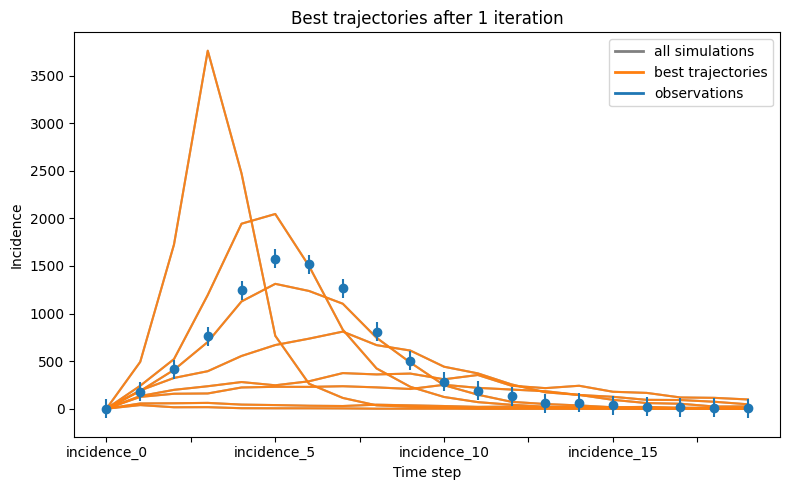

In [21]:
def plot_best_trajectories( observations, simulation_results, error, title ):

    # Get best trajectories
    n_top = 10
    top_results_idx = error.sort_values( ascending=True ).iloc[0:n_top].index
    top_trajectories = simulation_results.iloc[ top_results_idx ]

    # Draw plot
    colors = [ 'gray', 'tab:orange', 'tab:blue' ]
    fig, ax = plt.subplots( 1, 1, figsize=(8,5) )
    simulation_results.transpose().plot( color=colors[0], alpha=0.7, legend=False, ax=ax )
    top_trajectories.transpose().plot( color=colors[1], alpha=0.9, legend=False, ax=ax )
    observations['mean'].transpose().plot( yerr=observations['variance'].values, fmt='o', color=colors[2], legend=False, ax=ax )

    # Figure formatting
    from matplotlib.lines import Line2D
    lines = [ Line2D( [0], [0], color=color, lw=2 ) for color in colors ]
    legend_labels = [ 'all simulations', 'best trajectories', 'observations' ]
    ax.legend( lines, legend_labels )
    ax.set_title( title )
    ax.set_xlabel( 'Time step' )
    ax.set_ylabel( 'Incidence' )
    fig.tight_layout()
    
    return

plot_best_trajectories( observations, simulation_results, l2_relative_error_step_1, 'Best trajectories after 1 iteration' )

We can also check how what are the values of the parameters that lead to the best trajectories. This could give you a more refined version of the parameters that could explain the observation data (i.e., the solution space):

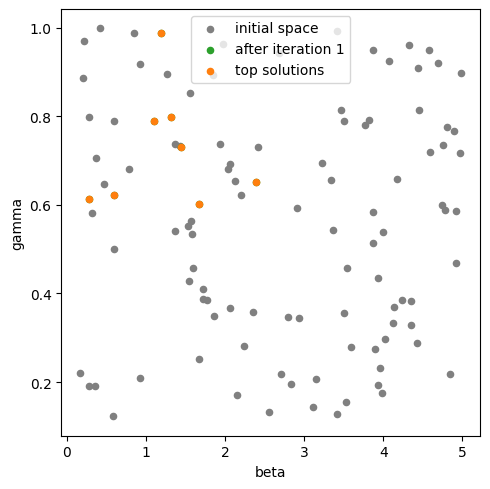

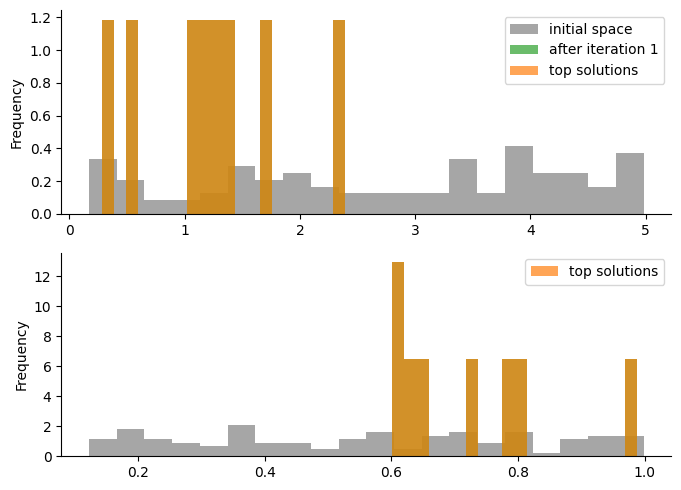

In [22]:
n_top = 10
top_solutions_idx = l2_relative_error_step_1.sort_values( ascending=True ).iloc[0:n_top].index
plot_parameter_space( test_points, samples_step_1, 'initial space', 'after iteration 1', top_solutions_idx )

### Evaluating the performance of the emulator

Sometimes, we may be interested in exploring the performance of the emulator. Some cases for that could trigger this type of exploration are, for example, the parametric space not being reduced as expected, we want to confirm that the reduction of the parametric space is based on a good emulator, we are designing a new emulator, or simply by curiousity.

We can check the performance of the emulator by looking at the `info` and `plot_diagnostics` methods of the emulator of interest. For the emulator that we trained in the first iteration, this is what we find:

... General information:
      Number of parameters =  3
      Number of samples (total) =  500
      Number of training samples =  1125
      Number of testing samples =  375

... Emulator configuration:
      model description:
╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │   value │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ GPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 12458.8 │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ GPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │     1   │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼

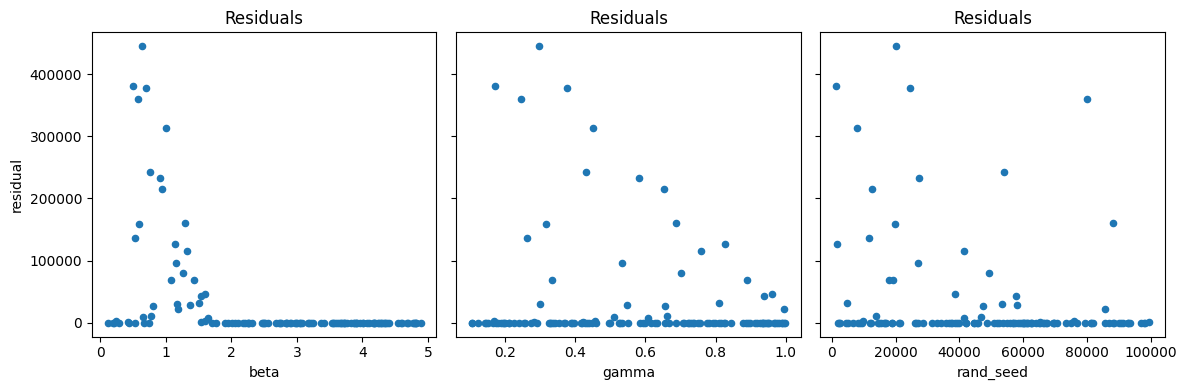

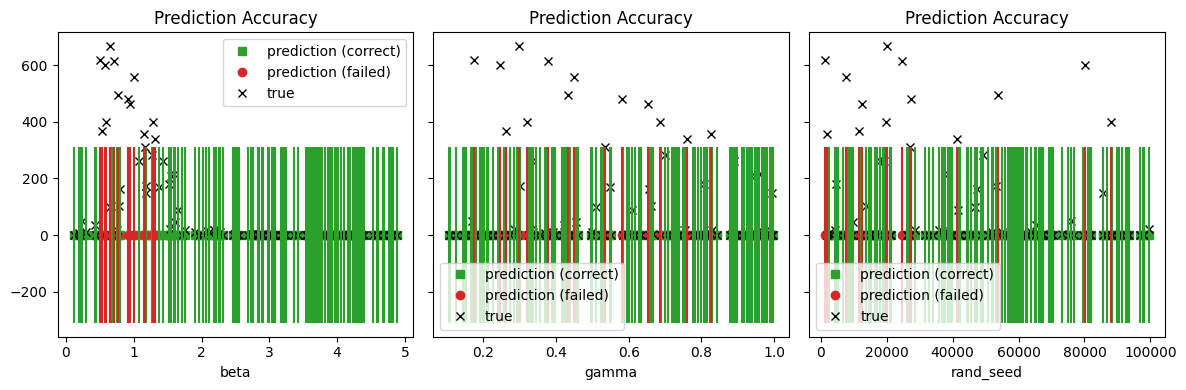

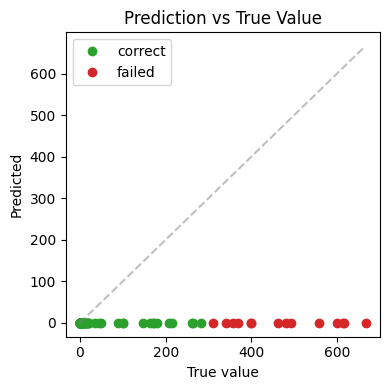

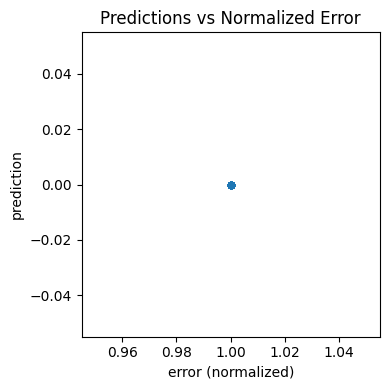

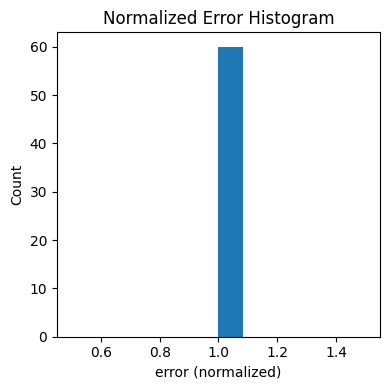

In [23]:
emulator_step_1 = trace[0]['emulators']['incidence_11']
emulator_step_1.info()
emulator_step_1.plot_diagnostics()

## Running multiple HM iterations

If we need to run additional iterations of the history matching algorihtm, we can do so by using the same `do_step` function and the `Config` instance that we used for the first iteration. This time, however, we should also include the `trace` as a parameter of the `do_step` function. This is needed so that the new step can use the result of the first (and every past) iteration. 

Another consideration when running an additional step is that, in general, we should select a different emulator targe than the ones used in previous iterations.

Let's try running another step of history matching using our example data.

In [ ]:
trace_2 = hm.do_step( config, trace )

Starting new History Matching iteration (iter=2)
... step_number = 2
... Running simulator


Loading BokehJS ...

And let's see what the second iteration did to our parameter space:

In [ ]:
samples_step_2 = trace[-1]['new_samples']
samples_step_2.head()

In [ ]:
plot_parameter_space( test_points, samples_step_2, 'initial space', 'after iteration 2' )

And let's check our best trajectory.  The solutions should be getting better with each iteration.

In [ ]:
simulation_results_step_2 = sir_model_wrapper( samples_step_2 )
l2_relative_error_step_2 = l2_relative_error( simulation_results_step_2, observations['mean'] )
plot_best_trajectories( observations, simulation_results_step_2, l2_relative_error_step_2, 'Best trajectories after 2 iterations' )

In [ ]:
n_top = 10
top_solutions_idx_step_2 = l2_relative_error_step_2.sort_values( ascending=True ).iloc[0:n_top].index
plot_parameter_space( test_points, samples_step_2, 'initial space', 'after iteration 2', top_solutions_idx_step_2 )